# 03 — Construção do Índice de Complexidade Processual

**Secções da dissertação:** 3.5.3 (dimensões e normalização) e 3.5.4
(agregação por média geométrica, sem pesos).

Calcula c(S), H̄, a normalização teórica e o min-max com ano-base fixo, e
agrega \(ICP = \sqrt{\bar{c}(S)\cdot\bar{H}}\). Grava `indice.parquet`.


In [1]:
# Arranque reproduzível: funciona a partir da raiz ou de notebooks/.
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def raiz_projeto() -> Path:
    cwd = Path.cwd().resolve()
    for cand in (cwd, cwd.parent, Path(".").resolve()):
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Não encontrei a raiz do projecto (pasta src/).")

RAIZ = raiz_projeto()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.caminhos import garantir_directorias
from src.config import aviso_parametros_pendentes, parametros_efectivos
from src.graficos_apa import CatalogoAPA, aplicar_estilo_apa, formatar_p

DIRS = garantir_directorias(RAIZ)
PARAM = parametros_efectivos(DIRS["processado"])
aplicar_estilo_apa()

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 88)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print(aviso_parametros_pendentes(PARAM))
print("Raiz:", RAIZ)


AVISO METODOLÓGICO — parâmetros ainda não validados com o orientador.
  Limiar mínimo de movimentos: 7 (EDA (parametros_sugeridos.json))
  Ano-base da normalização: 2016 (EDA (parametros_sugeridos.json))
  Coortes: [('TRF2', 2016), ('TRF2', 2017), ('TRF2', 2018), ('TRF2', 2019), ('TRF2', 2020), ('TRF2', 2021), ('TRF2', 2022), ('TRF2', 2023), ('TRF2', 2024)] (EDA (parametros_sugeridos.json))
  O índice produzido nesta corrida é operacional, não a versão final da dissertação.
Raiz: /workspace


In [2]:
from IPython.display import display, Markdown
from src.complexidade_lz import complexidade_lz, formatar_historia, historia_exaustiva
from src.entropia import entropia_normalizada, entropia_shannon
from src.normalizacao import (
    alfabeto_global,
    aplicar_minmax_ano_base,
    c_barra,
    estimar_limites_coorte_base,
    limite_teorico_lz,
)
from src.agregacao import agregar_icp, momentos_mpi_coorte_base

parquet = DIRS["processado"] / "processos_eda.parquet"
if not parquet.exists():
    raise FileNotFoundError(
        f"Artefacto em falta: {parquet}. Corra 02_eda.ipynb primeiro."
    )
quadro = pd.read_parquet(parquet)
PARAM = parametros_efectivos(DIRS["processado"])
print(aviso_parametros_pendentes(PARAM))
catalogo = CatalogoAPA(
    DIRS["figuras"], DIRS["tabelas"],
    DIRS["saidas"] / "relatorio_resultados.md",
    reiniciar_relatorio=False,
)
print("N (pós-EDA):", len(quadro))


AVISO METODOLÓGICO — parâmetros ainda não validados com o orientador.
  Limiar mínimo de movimentos: 7 (EDA (parametros_sugeridos.json))
  Ano-base da normalização: 2016 (EDA (parametros_sugeridos.json))
  Coortes: [('TRF2', 2016), ('TRF2', 2017), ('TRF2', 2018), ('TRF2', 2019), ('TRF2', 2020), ('TRF2', 2021), ('TRF2', 2022), ('TRF2', 2023), ('TRF2', 2024)] (EDA (parametros_sugeridos.json))
  O índice produzido nesta corrida é operacional, não a versão final da dissertação.
N (pós-EDA): 5247


## Dimensão estrutural: c(S) (Kaspar & Schuster, 1987)

Antes de tocar nos dados reais, validamos a implementação contra o exemplo
de Lempel & Ziv (1976, p. 76): a história exaustiva de `0001101001000101`
é `0 · 001 · 10 · 100 · 1000 · 101`, portanto **6** componentes. Se este
assert falhar, o teste unitário também falha — não se ajusta o alvo.


In [3]:
exemplo = "0001101001000101"
c_exemplo = complexidade_lz(exemplo)
partes = historia_exaustiva(exemplo)
print("c(S) =", c_exemplo)
print("H_E(S) =", formatar_historia(partes))
assert c_exemplo == 6, "A implementação não reproduz o exemplo da p. 76 — parar."
assert len(partes) == 6


c(S) = 6
H_E(S) = 0 · 001 · 10 · 100 · 1000 · 101


A sequência de entrada no DataJud não é binária: são códigos TPU (inteiros).
O algoritmo compara igualdade de símbolos, sem binarizar. Classe e duração
não entram (secção 3.4 / 3.5.4 — sem estimação de pesos).


In [4]:
quadro = quadro.copy()
quadro["c_s"] = quadro["sequencia_codigos"].map(complexidade_lz)
desc_c = quadro["c_s"].describe(percentiles=[0.25, 0.50, 0.75])
tab_c = pd.DataFrame({
    "estatística": ["n", "média", "desvio-padrão", "mín", "P25", "mediana", "P75", "máx"],
    "c(S)": [desc_c["count"], desc_c["mean"], desc_c["std"], desc_c["min"],
             desc_c["25%"], desc_c["50%"], desc_c["75%"], desc_c["max"]],
})
catalogo.nova_tabela(
    tab_c,
    titulo="Distribuição da complexidade de Lempel-Ziv c(S) na amostra de construção",
    nota="c(S) é o número de componentes da história exaustiva da sequência de códigos de movimento (Lempel & Ziv, 1976; Kaspar & Schuster, 1987). Ainda sem normalização.",
    nome_ficheiro="tabela_descritivas_c_s",
    interpretacao="c(S) cresce com n mas não linearmente; a normalização pelo Teorema 2 existe precisamente para separar complexidade de mero comprimento.",
)
display(quadro[["numero_processo", "n_movimentos", "c_s", "coorte"]].head())


estatística,c(S)
n,5247.00
média,9.34
desvio-padrão,3.15
mín,3.00
P25,7.00
mediana,9.00
P75,11.00
máx,27.00


,numero_processo,n_movimentos,c_s,coorte
0,00953390720164025117,11,9,2016
1,00997536320164025112,34,15,2016
2,00969703420164025101,13,7,2016
3,00956253320164025101,11,10,2016
4,01011601320164025110,8,6,2016


## Dimensão probabilística: H̄ (Pielou)

\(H = -\sum p_k \log_2 p_k\), depois \(\bar{H} = H / \log_2 k\), k = códigos
distintos *naquele* processo. Se k = 1, H̄ = 0 por convenção (não 0/0):
tramitação mono-símbolo não tem heterogeneidade de tipos (secção 3.5.3).


In [5]:
quadro["h_shannon"] = quadro["sequencia_codigos"].map(entropia_shannon)
quadro["h_barra"] = quadro["sequencia_codigos"].map(entropia_normalizada)
tab_h = quadro[["h_shannon", "h_barra", "k_alfabeto_processo"]].describe().T.reset_index().rename(columns={"index": "variável"})
catalogo.nova_tabela(
    tab_h,
    titulo="Entropia de Shannon e equitabilidade de Pielou (H̄) por processo",
    nota="H̄ ∈ [0, 1] por construção. k = 1 ⇒ H̄ = 0 (convenção, secção 3.5.3). Base do logaritmo = 2 (bits).",
    nome_ficheiro="tabela_descritivas_entropia",
    interpretacao="H̄ mede heterogeneidade de tipos, não ordem: dois processos com a mesma multiconjunto de movimentos têm o mesmo H̄ e podem ter c(S) diferente.",
)


variável,count,mean,std,min,25%,50%,75%,max
h_shannon,5247.00,2.76,0.37,1.06,2.52,2.75,3.00,3.82
h_barra,5247.00,0.91,0.08,0.43,0.88,0.93,0.97,1.00
k_alfabeto_processo,5247.00,8.41,2.15,3.00,7.00,8.00,10.00,17.00


,variável,count,mean,std,min,25%,50%,75%,max
0,h_shannon,5247.0,2.759515,0.369757,1.061278,2.521641,2.752715,3.000000,3.820889
1,h_barra,5247.0,0.912905,0.078254,0.433769,0.875701,0.931582,0.970836,1.000000
2,k_alfabeto_processo,5247.0,8.411092,2.153395,3.000000,7.000000,8.000000,10.000000,17.000000


## Normalização teórica de c(S) (Teorema 2)

Majorante \(c(S) < n / ((1-\varepsilon_n)\log_\alpha n)\), com
\(\varepsilon_n = 2(1+\log_\alpha\log_\alpha(\alpha n))/\log_\alpha n\).
α é o alfabeto *global* da amostra, para o bound não herdar duas vezes a
diversidade local (já capturada em H̄). Para n pequeno, ε_n pode ser ≥ 1:
recuamos então a \(n/\log_\alpha n\) (Aboy et al., 2006) em vez de inventar um ε.


In [6]:
alfa = alfabeto_global(quadro["sequencia_codigos"])
print("α global =", alfa)
quadro["limite_teorico_b_n"] = [
    limite_teorico_lz(int(n), alfa) for n in quadro["n_movimentos"]
]
quadro["c_barra"] = [
    c_barra(int(c), int(n), alfa)
    for c, n in zip(quadro["c_s"], quadro["n_movimentos"])
]
n_clip = int((quadro["c_s"] / quadro["limite_teorico_b_n"] > 1).sum())
print("Processos com c(S)/b(n) > 1 (cortados a 1):", n_clip)
display(quadro[["n_movimentos", "c_s", "limite_teorico_b_n", "c_barra", "h_barra"]].head())


α global = 112
Processos com c(S)/b(n) > 1 (cortados a 1): 0


,n_movimentos,c_s,limite_teorico_b_n,c_barra,h_barra
0,11,9,21.645436,0.415792,0.971326
1,34,15,45.494203,0.329712,0.809330
2,13,7,23.914891,0.292705,0.879714
3,11,10,21.645436,0.461991,0.986660
4,8,6,18.152946,0.330525,0.967132


## Min-max com ano-base fixo

Os min/máx de c̄ e H̄ da **primeira coorte** reescalam todas as coortes
seguintes. Não há recálculo automático quando chega um painel novo
(secção 3.5.3): se algum valor sair do intervalo, o código *avisa* e
não altera os limites.


In [7]:
ano_base = PARAM["ANO_BASE"]
if ano_base is None:
    ano_base = int(quadro["coorte"].min())
    print("ANO_BASE indefinido — a usar a primeira coorte observada:", ano_base)
else:
    ano_base = int(ano_base)
print("Ano-base efectivo:", ano_base)

limites = estimar_limites_coorte_base(quadro, ano_base)
print("Limites da coorte-base:", limites.para_dicionario())
quadro, avisos_mm = aplicar_minmax_ano_base(quadro, limites, clipar=True)
for aviso in avisos_mm:
    print(aviso)

import json
(DIRS["processado"] / "limites_normalizacao.json").write_text(
    json.dumps(limites.para_dicionario(), ensure_ascii=False, indent=2), encoding="utf-8"
)


Ano-base efectivo: 2016


Limites da coorte-base: {'ano_base': 2016, 'c_barra_min': 0.17276137567075045, 'c_barra_max': 0.5266307606651952, 'h_barra_min': 0.5776723119652726, 'h_barra_max': 1.0, 'n_processos_base': 645, 'avisos': []}
AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.
AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.


199

## Agregação: média geométrica (especificação principal)

\(ICP = \sqrt{\bar{c}(S)\cdot\bar{H}}\). Agregação não compensatória: se uma
dimensão é 0, o índice é 0. Sem pesos (secção 3.5.4). A média aritmética e o
MPI calculam-se já aqui, mas só se interpretam no notebook 05 (robustez).


In [8]:
momentos = momentos_mpi_coorte_base(quadro, ano_base)
quadro = agregar_icp(quadro, momentos_mpi=momentos)

tab_icp = quadro[["c_barra_mm", "h_barra_mm", "icp", "icp_aritmetica", "icp_mpi"]].describe().T.reset_index().rename(columns={"index": "variável"})
catalogo.nova_tabela(
    tab_icp,
    titulo="Descritivas das dimensões normalizadas e do ICP (especificação principal e alternativas)",
    nota="c̄_mm e H̄_mm: min-max da coorte-base. ICP = média geométrica. Aritmética e MPI apenas para a secção 3.5.7. Sem pesos.",
    nome_ficheiro="tabela_descritivas_icp",
    interpretacao="O ICP geométrico situa-se entre as duas dimensões e penaliza desequilíbrios; comparar a média do ICP com a da aritmética na robustez (notebook 05).",
)

por_coorte = (
    quadro.groupby("coorte")[["icp", "c_barra_mm", "h_barra_mm", "n_movimentos", "duracao_dias"]]
    .median()
    .reset_index()
)
catalogo.nova_tabela(
    por_coorte,
    titulo="Medianas do ICP e das dimensões por coorte de ajuizamento",
    nota=f"Coorte = ano de ajuizamento. Ano-base da normalização min-max = {ano_base}. A duração em dias é critério externo, não insumo.",
    nome_ficheiro="tabela_medianas_icp_por_coorte",
    interpretacao="A comparabilidade entre painéis é o teste prático do ano-base fixo: medianas que saltam de forma implausível entre coortes adjacentes devem levar a inspeccionar o limiar e a composição por classe, não a reestimar pesos.",
)


variável,count,mean,std,min,25%,50%,75%,max
c_barra_mm,5247.00,0.57,0.17,0.00,0.45,0.57,0.69,1.00
h_barra_mm,5247.00,0.79,0.18,0.00,0.71,0.84,0.93,1.00
icp,5247.00,0.67,0.16,0.00,0.59,0.68,0.78,1.00
icp_aritmetica,5247.00,0.68,0.15,0.00,0.61,0.69,0.79,1.00
icp_mpi,5247.00,99.79,9.52,56.37,95.44,100.90,106.09,117.62


coorte,icp,c_barra_mm,h_barra_mm,n_movimentos,duracao_dias
2016.00,0.65,0.54,0.84,12.00,3105.93
2017.00,0.64,0.48,0.87,11.00,2818.07
2018.00,0.69,0.54,0.86,11.00,2435.22
2019.00,0.64,0.51,0.86,11.00,1910.10
2020.00,0.67,0.59,0.76,16.00,1634.76
2021.00,0.68,0.56,0.82,11.00,1282.00
2022.00,0.68,0.60,0.79,15.00,873.93
2023.00,0.73,0.63,0.85,12.00,512.10
2024.00,0.71,0.60,0.89,9.00,275.52


,coorte,icp,c_barra_mm,h_barra_mm,n_movimentos,duracao_dias
0,2016,0.653277,0.535282,0.836210,12.0,3105.927928
1,2017,0.641192,0.477104,0.873113,11.0,2818.073738
2,2018,0.686388,0.544393,0.860200,11.0,2435.220752
3,2019,0.642145,0.510710,0.864278,11.0,1910.101117
4,2020,0.670125,0.593025,0.759367,16.0,1634.760625
5,2021,0.679737,0.556227,0.820813,11.0,1282.000949
6,2022,0.678564,0.601496,0.787924,15.0,873.928235
7,2023,0.731836,0.627948,0.851281,12.0,512.104745
8,2024,0.709009,0.601496,0.885862,9.0,275.517280


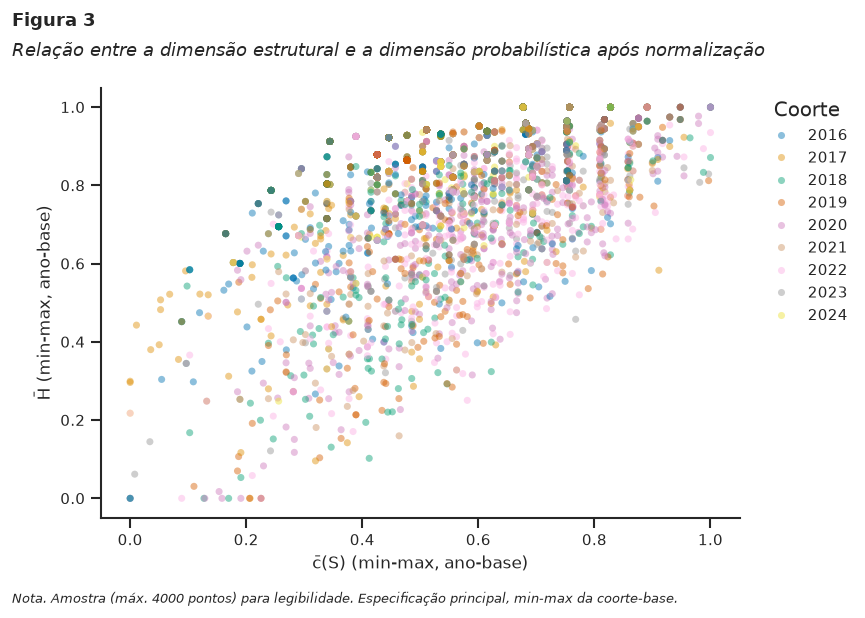

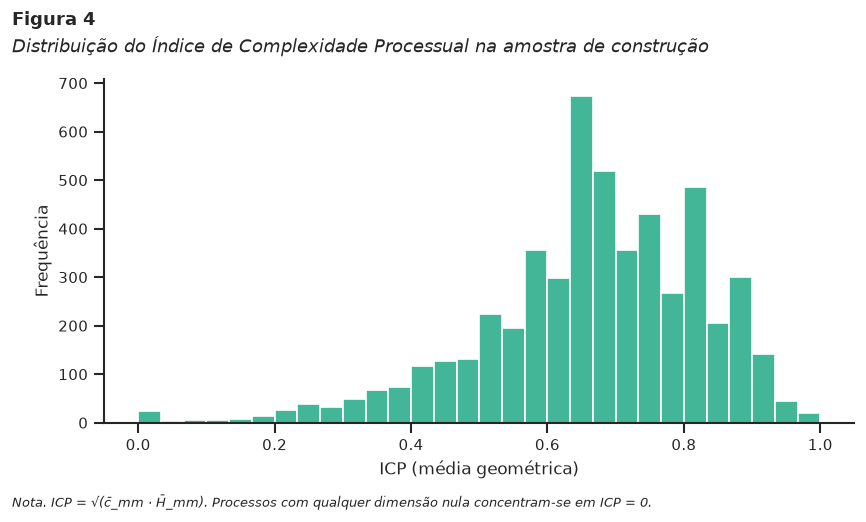

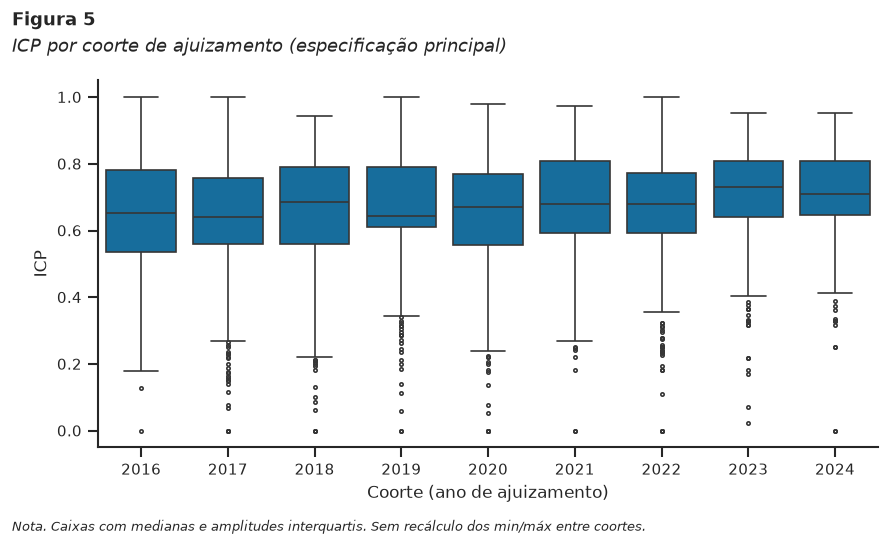

Gravado indice.parquet com 5247 processos


In [9]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
sns.scatterplot(
    data=quadro.sample(min(len(quadro), 4000), random_state=42),
    x="c_barra_mm", y="h_barra_mm", hue="coorte",
    palette="colorblind", alpha=0.45, s=18, ax=ax, edgecolor="none",
)
ax.set_xlabel("c̄(S) (min-max, ano-base)")
ax.set_ylabel("H̄ (min-max, ano-base)")
ax.legend(title="Coorte", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
catalogo.nova_figura(
    fig,
    titulo="Relação entre a dimensão estrutural e a dimensão probabilística após normalização",
    nota="Amostra (máx. 4000 pontos) para legibilidade. Especificação principal, min-max da coorte-base.",
    nome_ficheiro="figura_dispersao_c_h",
    interpretacao="Uma nuvem alongada mas não colinear é a geometria esperada de duas dimensões relacionadas e não redundantes (secção 3.5.8); colinearidade estrita invalidaria a média geométrica.",
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.histplot(quadro["icp"], bins=30, ax=ax, color=sns.color_palette("colorblind")[2], edgecolor="white")
ax.set_xlabel("ICP (média geométrica)")
ax.set_ylabel("Frequência")
catalogo.nova_figura(
    fig,
    titulo="Distribuição do Índice de Complexidade Processual na amostra de construção",
    nota="ICP = √(c̄_mm · H̄_mm). Processos com qualquer dimensão nula concentram-se em ICP = 0.",
    nome_ficheiro="figura_histograma_icp",
    interpretacao="A forma da distribuição (massa em zero vs. sino) diz se a não-compensação da média geométrica está a 'achatar' muitos processos ou a preservar discriminação no miolo.",
)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
sns.boxplot(
    data=quadro, x="coorte", y="icp", ax=ax,
    color=sns.color_palette("colorblind")[0], fliersize=2,
)
ax.set_xlabel("Coorte (ano de ajuizamento)")
ax.set_ylabel("ICP")
catalogo.nova_figura(
    fig,
    titulo="ICP por coorte de ajuizamento (especificação principal)",
    nota="Caixas com medianas e amplitudes interquartis. Sem recálculo dos min/máx entre coortes.",
    nome_ficheiro="figura_boxplot_icp_por_coorte",
    interpretacao="A estabilidade (ou deriva) das caixas ao longo do tempo é o primeiro sinal visual da comparabilidade entre painéis que a secção 3.5.6 monitoriza formalmente.",
)

cols_gravar = [c for c in quadro.columns if c != "movimentos"]
# movimentos ficam no parquet da EDA; o índice guarda a sequência e os scores.
quadro.drop(columns=["assuntos"], errors="ignore").to_parquet(
    DIRS["processado"] / "indice.parquet", index=False
)
print("Gravado indice.parquet com", len(quadro), "processos")


## Síntese

- c(S) reproduz o exemplo LZ 1976 (6 componentes) antes de ser aplicado aos dados.
- H̄ ∈ [0, 1]; k = 1 ⇒ 0 por convenção.
- c̄ usa o Teorema 2 com α global; min-max usa ano-base fixo e *avisa* se houver extrapolação.
- ICP = média geométrica; sem pesos. Artefacto: `data/processado/indice.parquet`.
